In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv("../data/raw/loan_book.csv")

df.head()

,applicant_id_hash,age,annual_income,employment_length_years,home_ownership,region,num_open_accounts,num_delinquencies_2yr,total_revolving_balance,credit_utilisation_pct,months_since_oldest_account,num_hard_inquiries_6mo,loan_amount,interest_rate,loan_purpose,dti_ratio,months_since_last_delinquency,pct_accounts_current,application_date,application_dow,branch_code_id,months_at_current_address,email_domain_type,phone_verified,default_flag,set
0,11a2f242b28a331c,35.5,29401.0,3.6,MORTGAGE,North-Urban,9.0,7,1778.0,12.7,177.0,2,16326.0,21.11,major_purchase,0.245,1.0,50.9,06/14/2021,Monday,347,119,other,True,0,test
1,5afff059dc04c6f0,25.0,32005.0,1.4,mortgage,South-Urban,10.0,0,0.0,31.2,42.0,1,8293.0,12.69,medical,0.337,105.0,93.0,2021-08-28,Friday,367,7,free,False,0,train
2,eb85b183be0505f3,40.0,26730.0,NaN,MORTGAGE,East-Urban,9.0,0,3690.0,29.4,148.0,0,13080.0,10.45,debt_consolidation,0.124,NaN,87.9,2021-02-23,Saturday,895,142,free,True,0,test
3,7d99629563bdb528,30.9,60105.0,7.5,MORTGAGE,South-Suburban,7.0,0,7636.0,48.8,115.0,2,6752.0,15.26,other,0.218,58.0,96.1,2021-10-07,Thursday,387,69,other,True,1,test
4,658f1f05e484ce14,49.1,112275.0,6.9,MORTGAGE,East-Suburban,10.0,0,14450.0,68.2,324.0,3,19144.0,9.04,other,0.195,NaN,90.8,23-Aug-2021,Sunday,561,182,free,True,0,test


In [3]:
print(df.shape)

(120960, 26)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120960 entries, 0 to 120959
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   applicant_id_hash              120960 non-null  str    
 1   age                            120960 non-null  float64
 2   annual_income                  112269 non-null  float64
 3   employment_length_years        117236 non-null  float64
 4   home_ownership                 120960 non-null  str    
 5   region                         120960 non-null  str    
 6   num_open_accounts              118523 non-null  float64
 7   num_delinquencies_2yr          120960 non-null  int64  
 8   total_revolving_balance        120960 non-null  float64
 9   credit_utilisation_pct         120960 non-null  float64
 10  months_since_oldest_account    120960 non-null  float64
 11  num_hard_inquiries_6mo         120960 non-null  int64  
 12  loan_amount                    120960 non

In [7]:
df['application_date'] = pd.to_datetime(
    df['application_date'],
    format='mixed'
)

In [8]:
df['application_date'].dtype

dtype('<M8[us]')

In [9]:
df['application_date'].isnull().sum()

np.int64(0)

In [10]:
df['application_date'].min(), df['application_date'].max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percent Missing': missing_percent
})

missing_df = missing_df[missing_df['Missing Values'] > 0]

missing_df

,Missing Values,Percent Missing
months_since_last_delinquency,60380,49.917328
annual_income,8691,7.185020
employment_length_years,3724,3.078704
num_open_accounts,2437,2.014716


In [12]:
df['default_flag'].value_counts()

default_flag
0    102289
1     18671
Name: count, dtype: int64

In [13]:
df['default_flag'].value_counts(normalize=True) * 100

default_flag
0    84.564319
1    15.435681
Name: proportion, dtype: float64

In [14]:
df['default_label'] = df['default_flag'].map({
    0: 'Non-Default',
    1: 'Default'
})


In [15]:
numerical_cols = [
    'age',
    'annual_income',
    'employment_length_years',
    'num_open_accounts',
    'num_delinquencies_2yr',
    'total_revolving_balance',
    'credit_utilisation_pct',
    'months_since_oldest_account',
    'num_hard_inquiries_6mo',
    'loan_amount',
    'interest_rate',
    'dti_ratio',
    'months_since_last_delinquency',
    'pct_accounts_current',
    'months_at_current_address'
]

In [16]:
def plot_feature_vs_target(feature):

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Histogram
    sns.histplot(
        data=df,
        x=feature,
        hue='default_label',
        kde=True,
        bins=30,
        ax=axes[0]
    )

    axes[0].set_title(f'{feature} Distribution')

    # Boxplot
    sns.boxplot(
        data=df,
        x='default_label',
        y=feature,
        ax=axes[1]
    )

    axes[1].set_title(f'{feature} vs Default')

    plt.tight_layout()
    plt.show()

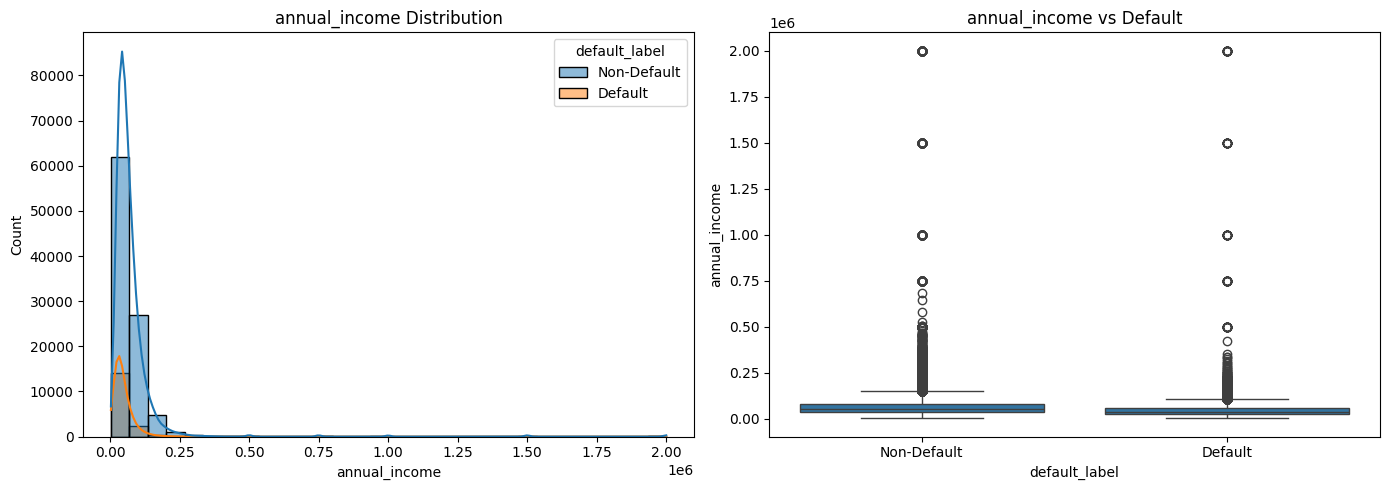

In [17]:
plot_feature_vs_target('annual_income')

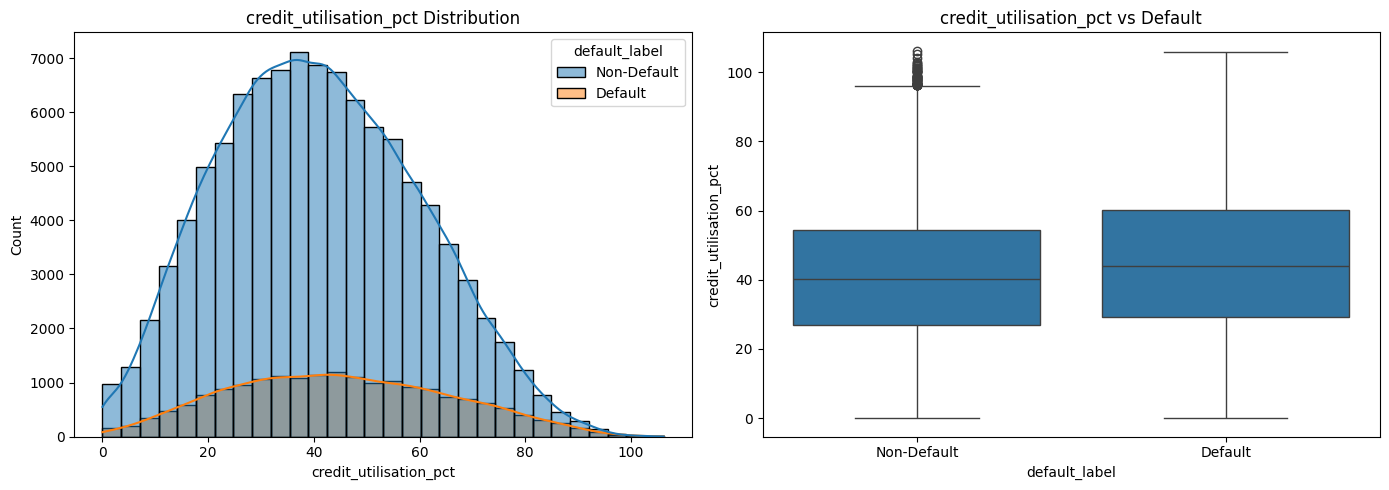

In [18]:
plot_feature_vs_target('credit_utilisation_pct')

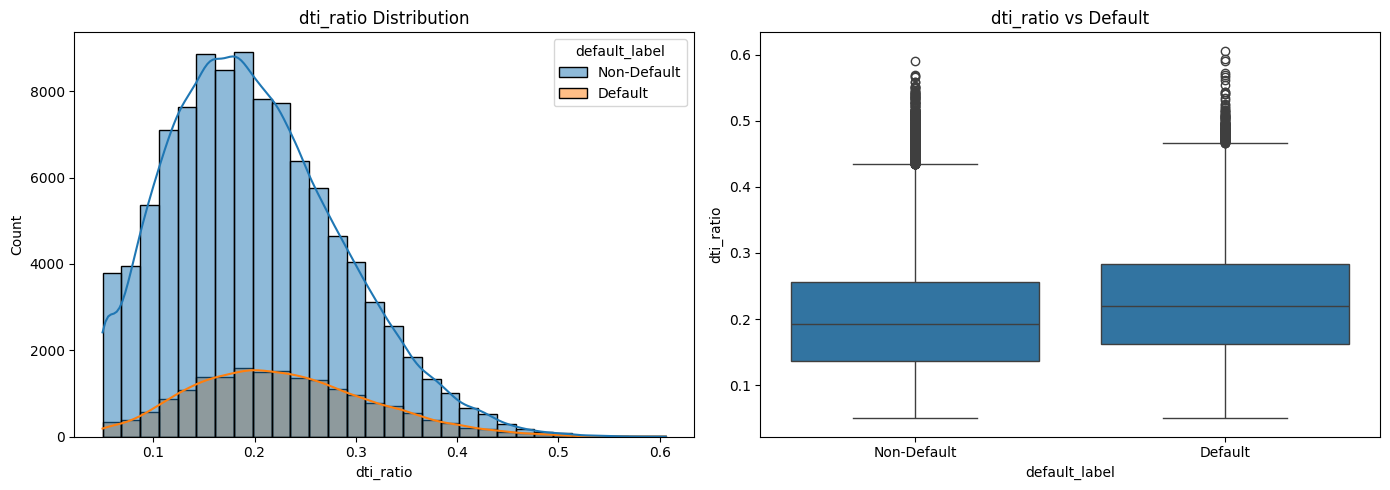

In [19]:
plot_feature_vs_target('dti_ratio')

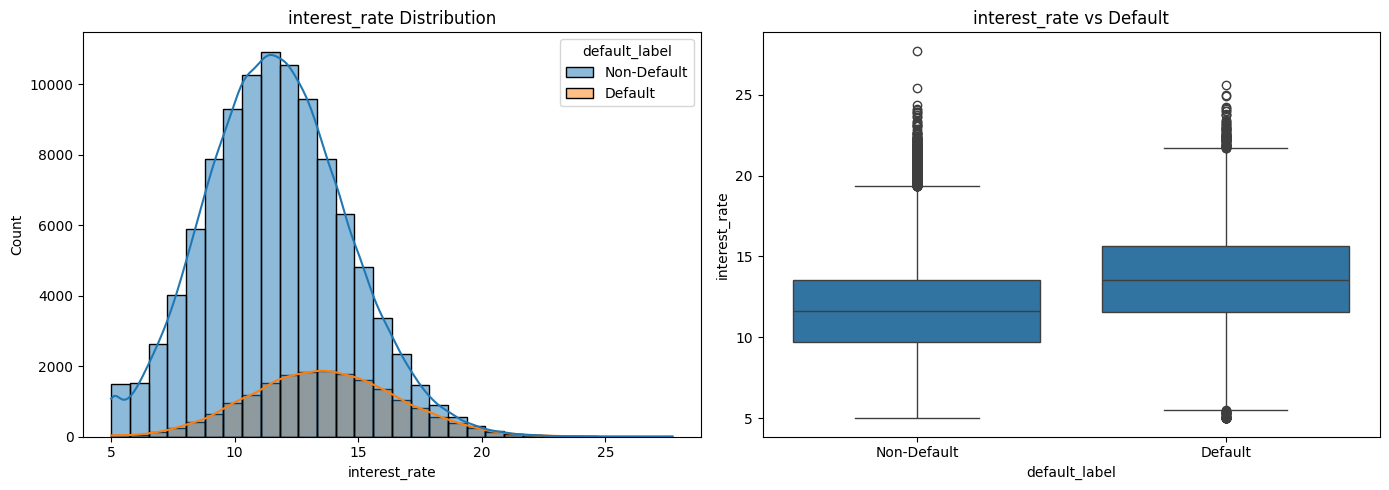

In [20]:
plot_feature_vs_target('interest_rate')

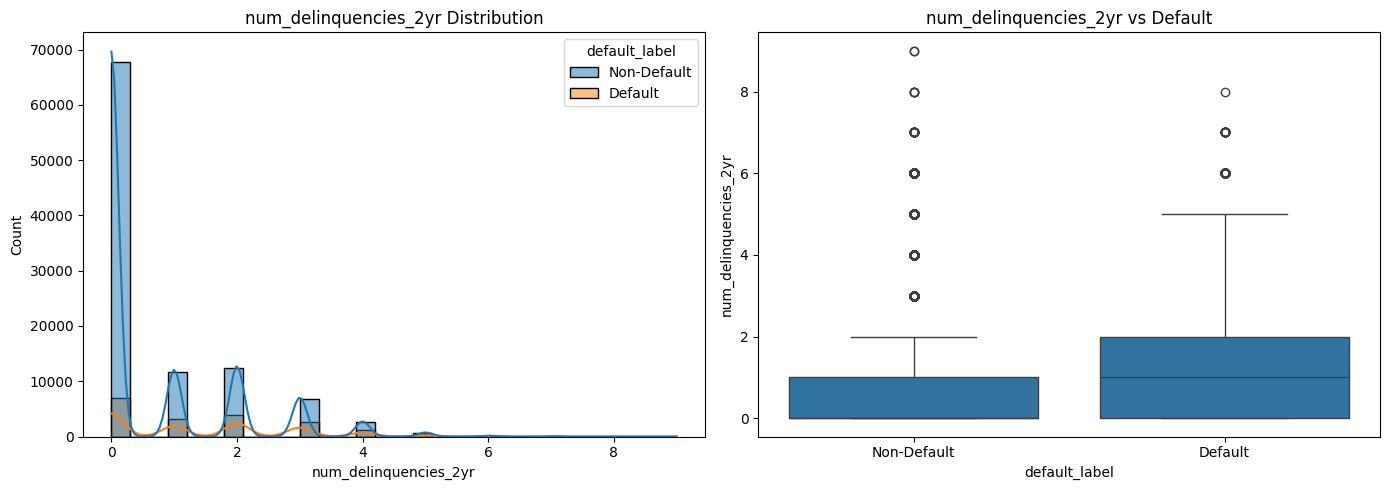

In [21]:
plot_feature_vs_target('num_delinquencies_2yr')

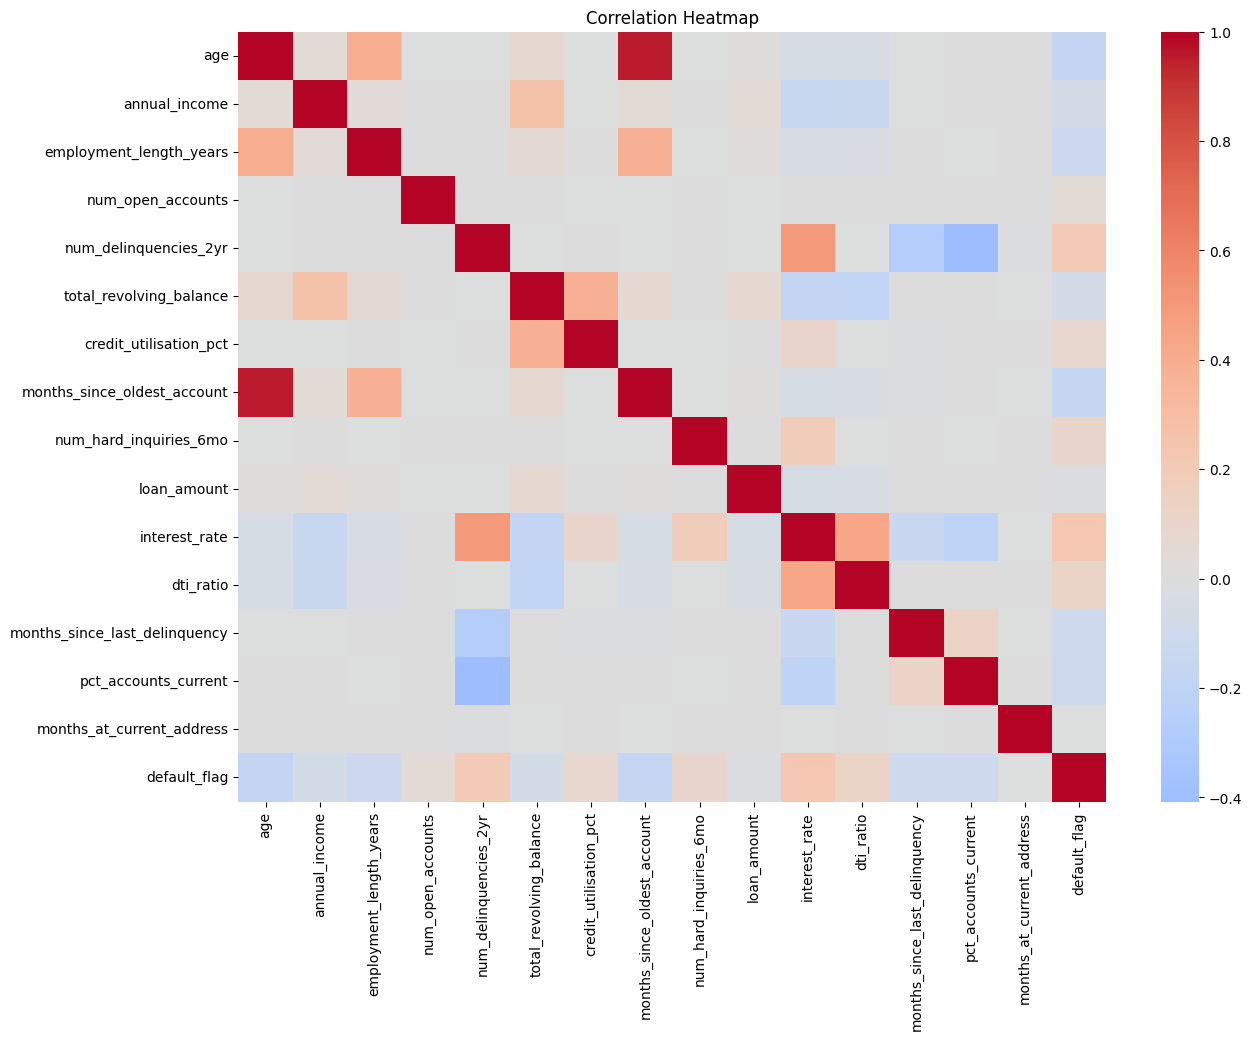

In [22]:
plt.figure(figsize=(14,10))

corr = df[numerical_cols + ['default_flag']].corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

In [23]:
def plot_categorical_default_rate(feature):

    plt.figure(figsize=(10,5))

    default_rates = (
        df.groupby(feature)['default_flag']
        .mean()
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=default_rates.index,
        y=default_rates.values
    )

    plt.xticks(rotation=45)

    plt.ylabel('Default Rate')

    plt.title(f'Default Rate by {feature}')

    plt.show()

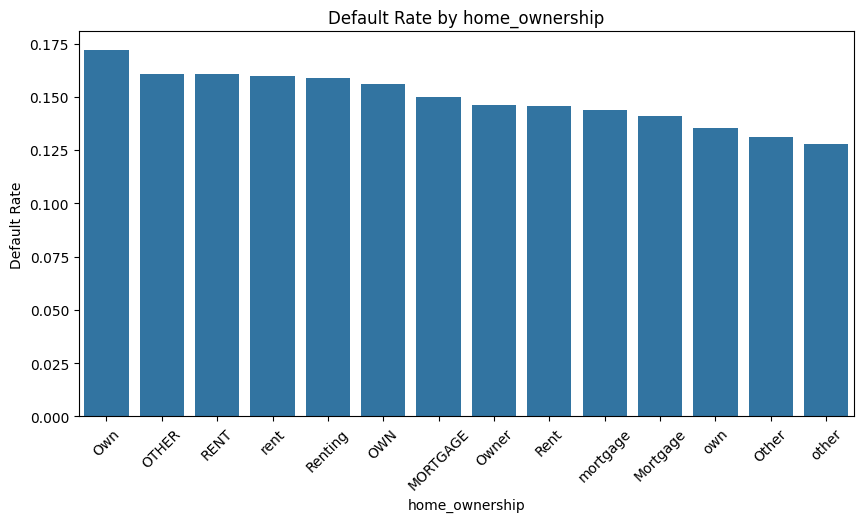

In [24]:
plot_categorical_default_rate('home_ownership')

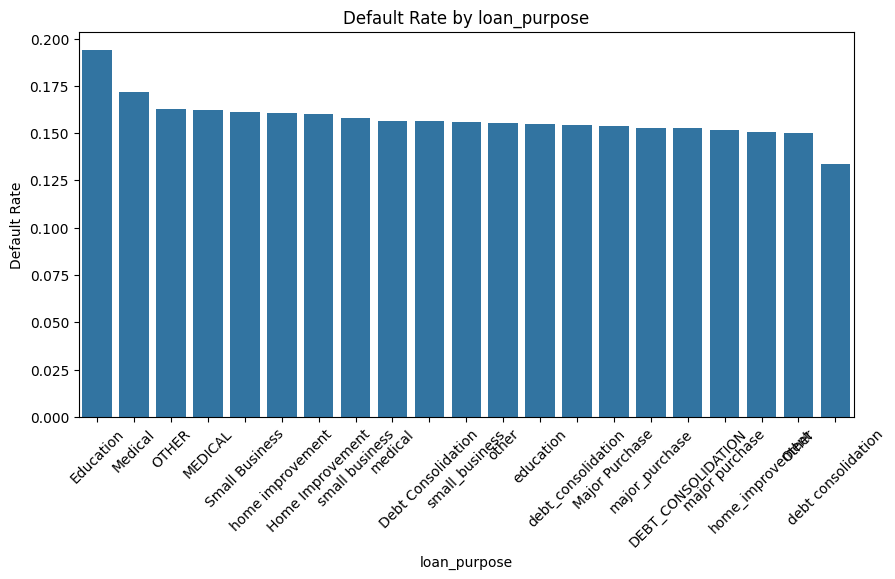

In [25]:
plot_categorical_default_rate('loan_purpose')

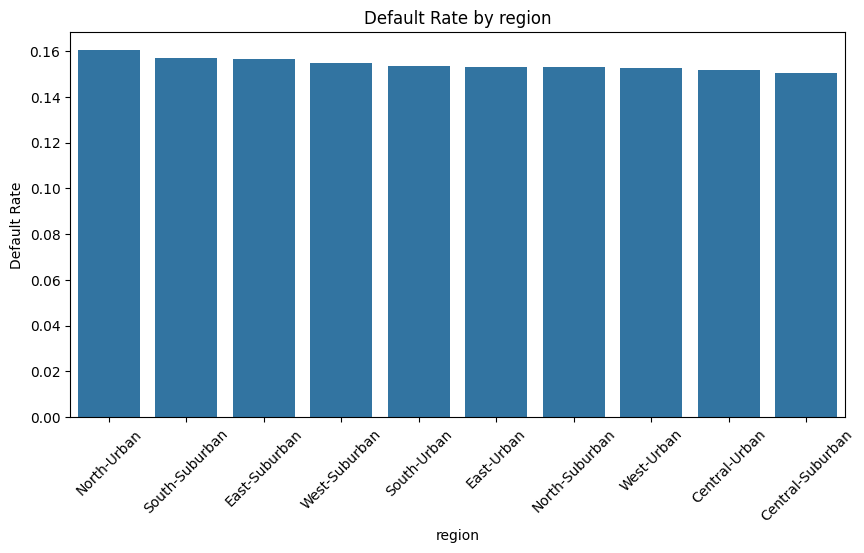

In [26]:
plot_categorical_default_rate('region')

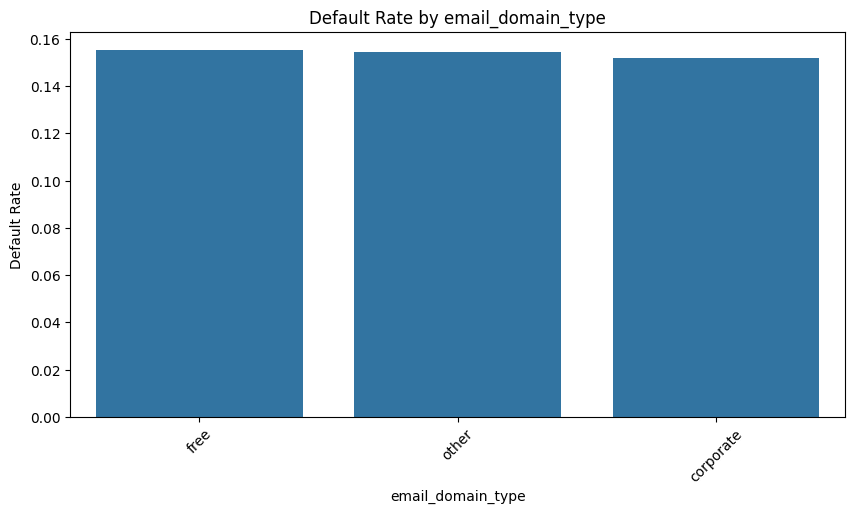

In [27]:
plot_categorical_default_rate('email_domain_type')

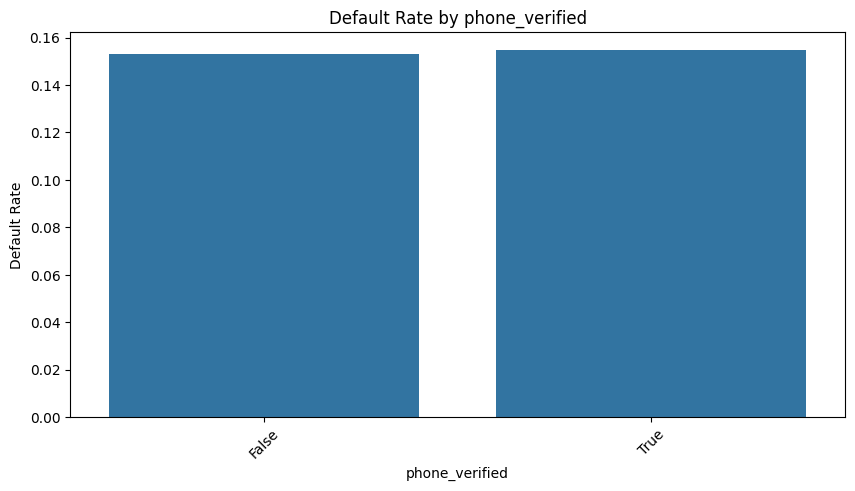

In [28]:
plot_categorical_default_rate('phone_verified')